# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [T.Sofia Chairani]
- **Email:** [tsofiachairani@mhs.unimed.ac.id]
- **ID Dicoding:** [tsofiachairani]

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh suhu (temp), kecepatan angin dan kelembapan terhadap rata-rata jumlah peminjaman sepeda pengguna casual pada akhir pekan (weekend) selama periode 2011-2012?
- Bagaimana perbandingan rata-rata jumlah peminjaman pengguna casual dan registered pada setiap musim selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [32]:
# Gathering Data
from google.colab import files
import os, shutil
import pandas as pd

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
upload_dir = "/content/Bike-sharing-dataset"
os.makedirs(upload_dir, exist_ok=True)

uploaded = files.upload()

for filename in uploaded:
    shutil.move(
        f"/content/{filename}",
        os.path.join(upload_dir, filename)
    )

print("File tersimpan di:", upload_dir)

Saving day.csv to day.csv
Saving hour.csv to hour.csv
File tersimpan di: /content/Bike-sharing-dataset


In [3]:
df_day, df_hour = (
    pd.read_csv("Bike-sharing-dataset/day.csv"),
    pd.read_csv("Bike-sharing-dataset/hour.csv")
)

In [4]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df_hour.head()

**Insight:**
- Dataset df_day berisi data peminjaman sepeda yang telah diagregasi pada tingkat harian. Data ini digunakan untuk melihat tren dan pengaruh faktor lingkungan.
- Dataset df_hour berisi data peminjaman sepeda yang telah diagregasi pada tingkat jam. Data ini digunakan untuk memahami pola operasional dan perilaku pengguna dalam satu hari.

### Assessing Data

Mulai dari sini, yang digunakan hanya dataset df_day. Karena df_hour tidak diperlukan dalam analisis berdasarkan pertanyaan yang dirumuskan

In [6]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
df_day.duplicated().sum()

np.int64(0)

In [8]:
pd.Series({
    "season": df_day["season"].isin([1,2,3,4]).all(),
    "yr": df_day["yr"].isin([0,1]).all(),
    "mnth": df_day["mnth"].between(1,12).all(),
    "weekday": df_day["weekday"].between(0,6).all(),
    "workingday": df_day["workingday"].isin([0,1]).all(),
    "holiday": df_day["holiday"].isin([0,1]).all(),
    "weathersit": df_day["weathersit"].between(1,4).all(),
    "cnt_logic": (df_day["cnt"] == df_day["casual"] + df_day["registered"]).all(),
    "numeric_range": ((df_day[["temp","atemp","hum","windspeed"]] >= 0).all().all() and
                      (df_day[["temp","atemp","hum","windspeed"]] <= 1).all().all())
})


,0
season,True
yr,True
mnth,True
weekday,True
workingday,True
holiday,True
weathersit,True
cnt_logic,True
numeric_range,True


In [10]:
df_day[["temp","atemp","hum","windspeed"]].describe()

,temp,atemp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486
std,0.183051,0.162961,0.142429,0.077498
min,0.059130,0.079070,0.000000,0.022392
25%,0.337083,0.337842,0.520000,0.134950
50%,0.498333,0.486733,0.626667,0.180975
75%,0.655417,0.608602,0.730209,0.233214
max,0.861667,0.840896,0.972500,0.507463


In [11]:
(df_day["cnt"] == df_day["casual"] + df_day["registered"]).all()

np.True_

In [12]:
(df_day[["casual","registered","cnt"]] < 0).any()

,0
casual,False
registered,False
cnt,False


<Axes: >

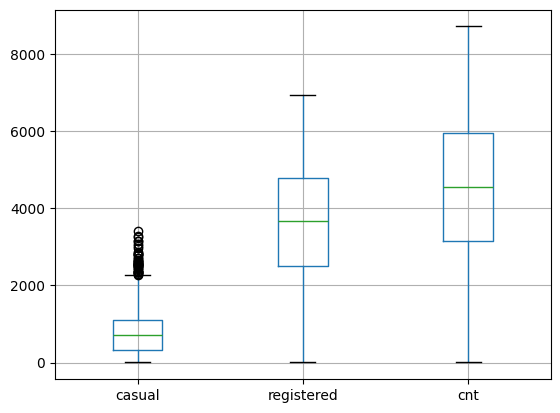

In [13]:
df_day[["casual","registered","cnt"]].boxplot()

**Insight:**
- Dataset harian tidak mengandung nilai hilang, duplikasi, maupun nilai di luar rentang yang didefinisikan, sehingga secara kualitas data dinilai baik dan konsisten. Ditemukan outlier pada variabel jumlah peminjaman yang merepresentasikan lonjakan aktivitas peminjaman pada hari tertentu, serta kolom tanggal (dteday) yang bertipe data object seharusnya datetime.
- Outlier pada jumlah peminjaman tidak dihapus karena merepresentasikan lonjakan aktivitas peminjaman yang valid dan mencerminkan kondisi nyata pada waktu tertentu.

### Cleaning Data

In [9]:
df_day["dteday"] = pd.to_datetime(df_day["dteday"], errors="coerce")
assert df_day["dteday"].notna().all()

In [23]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Kolom dteday pada data harian berhasil dikonversi dari tipe object menjadi tipe datetime tanpa menghasilkan nilai kosong. Hal ini menunjukkan bahwa seluruh informasi tanggal valid dan konsisten, sehingga data siap digunakan untuk analisis berbasis waktu seperti tren, pola musiman, dan perbandingan temporal.

## Exploratory Data Analysis (EDA)

### Explore ...

In [25]:
df_day.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


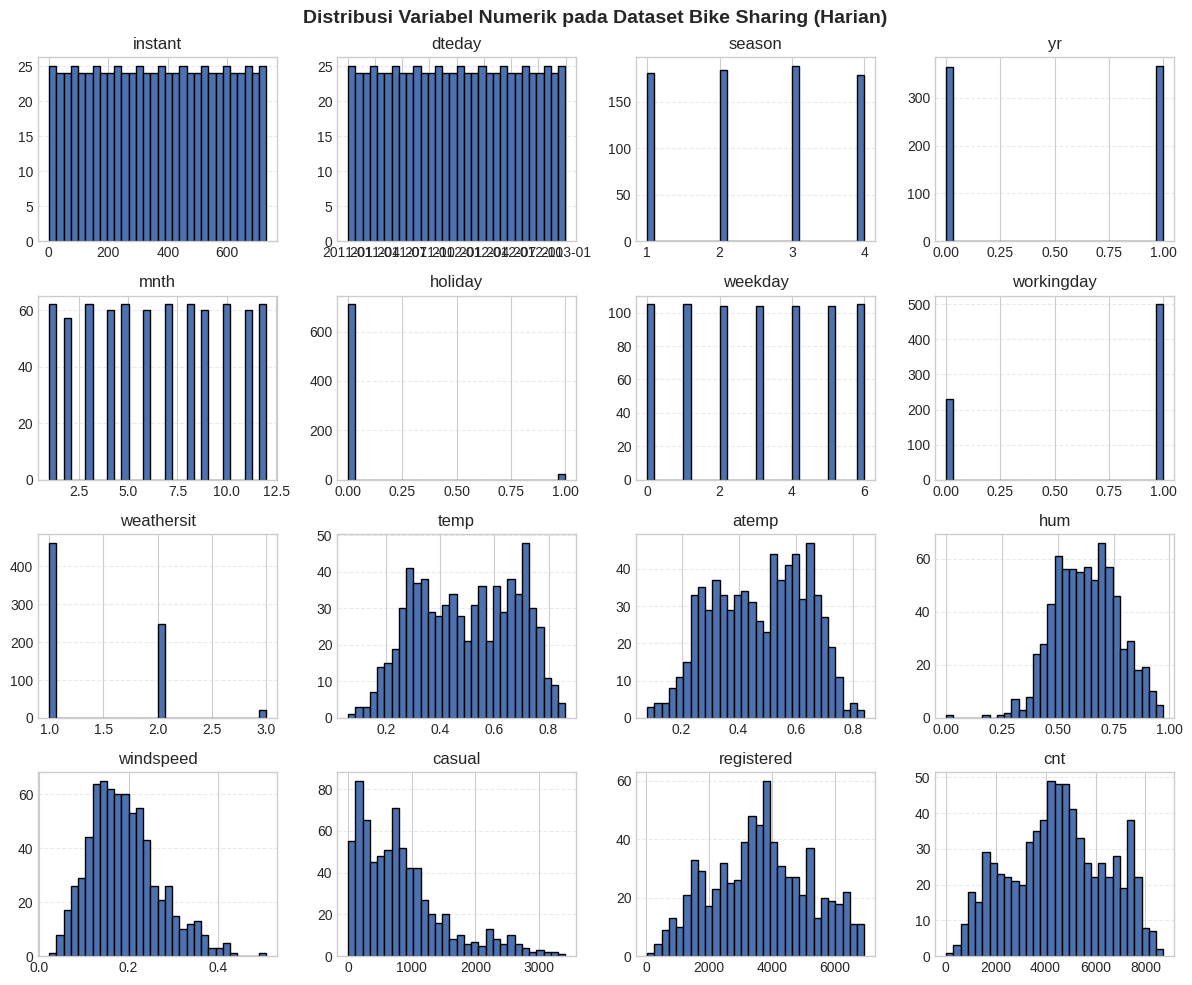

In [84]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

df_day.hist(
    figsize=(12,10),
    bins=30,
    edgecolor="black",
    color="#4C72B0"
)

plt.suptitle(
    "Distribusi Variabel Numerik pada Dataset Bike Sharing (Harian)",
    fontsize=14,
    weight="bold"
)

for ax in plt.gcf().axes:
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [28]:
df_day.corr()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,1.000000,0.412224,0.866025,0.496702,0.016145,-0.000016,-0.004337,-0.021477,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
dteday,1.000000,1.000000,0.412224,0.866025,0.496702,0.016145,-0.000016,-0.004337,-0.021477,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
season,0.412224,0.412224,1.000000,-0.001844,0.831440,-0.010537,-0.003080,0.012485,0.019211,0.334315,0.342876,0.205445,-0.229046,0.210399,0.411623,0.406100
yr,0.866025,0.866025,-0.001844,1.000000,-0.001792,0.007954,-0.005461,-0.002013,-0.048727,0.047604,0.046106,-0.110651,-0.011817,0.248546,0.594248,0.566710
mnth,0.496702,0.496702,0.831440,-0.001792,1.000000,0.019191,0.009509,-0.005901,0.043528,0.220205,0.227459,0.222204,-0.207502,0.123006,0.293488,0.279977
holiday,0.016145,0.016145,-0.010537,0.007954,0.019191,1.000000,-0.101960,-0.253023,-0.034627,-0.028556,-0.032507,-0.015937,0.006292,0.054274,-0.108745,-0.068348
weekday,-0.000016,-0.000016,-0.003080,-0.005461,0.009509,-0.101960,1.000000,0.035790,0.031087,-0.000170,-0.007537,-0.052232,0.014282,0.059923,0.057367,0.067443
workingday,-0.004337,-0.004337,0.012485,-0.002013,-0.005901,-0.253023,0.035790,1.000000,0.061200,0.052660,0.052182,0.024327,-0.018796,-0.518044,0.303907,0.061156
weathersit,-0.021477,-0.021477,0.019211,-0.048727,0.043528,-0.034627,0.031087,0.061200,1.000000,-0.120602,-0.121583,0.591045,0.039511,-0.247353,-0.260388,-0.297391
temp,0.150580,0.150580,0.334315,0.047604,0.220205,-0.028556,-0.000170,0.052660,-0.120602,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494


**Insight:**
##### Pertanyaan 1
- Sebagian besar data peminjaman terjadi saat suhu berada di rentang menengah–tinggi.
- Kondisi peminjaman paling sering terjadi pada kelembapan sedang
- Sebagian besar aktivitas peminjaman tercatat saat angin relatif tenang/kecepatan rendah
- Suhu memiliki hubungan positif yang cukup kuat dengan jumlah peminjaman sepeda oleh pengguna casual, sedangkan kelembapan dan kecepatan angin menunjukkan hubungan negatif yang lemah.
- Saat suhu meningkat, peminjaman casual cenderung meningkat.
- Angin kencang dan kelembapan tinggi cenderung menurunkan minat casual, meskipun pengaruhnya tidak sekuat suhu.

##### Pertanyaan 2
- Histogram menunjukkan bahwa peminjaman pengguna registered memiliki distribusi yang lebih stabil dan lebih tinggi dibandingkan pengguna casual.
- Analisis korelasi menunjukkan bahwa faktor musim memiliki hubungan yang lebih kuat terhadap peminjaman registered (0.41) dibandingkan casual (0.21).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

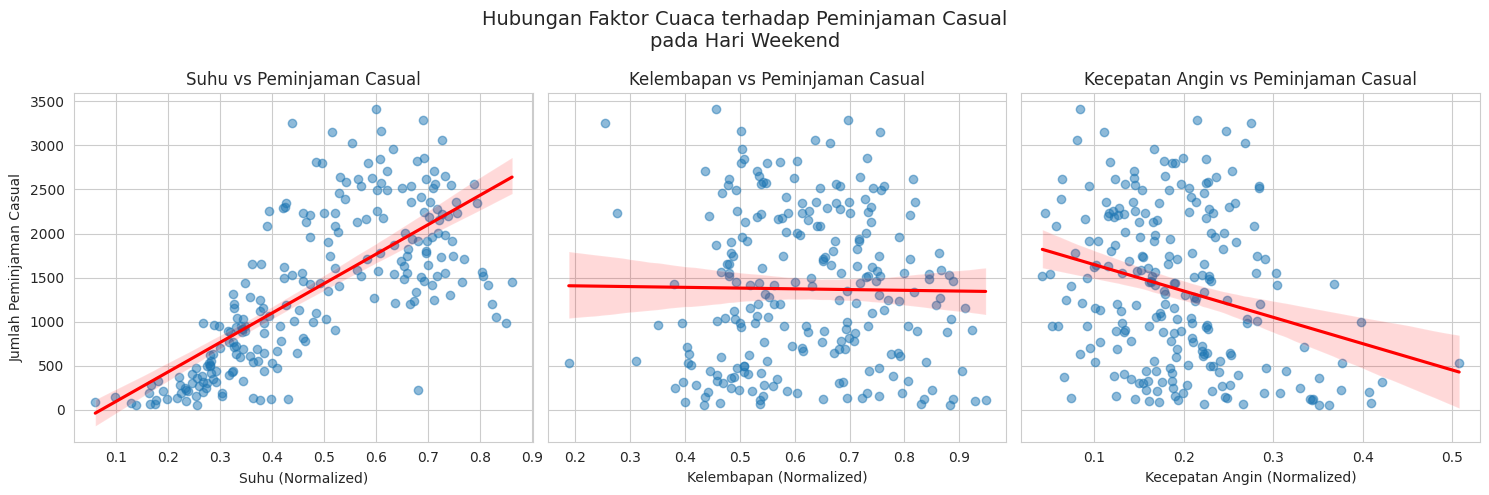

In [82]:
weekend = df_day[df_day["workingday"] == 0]

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

# Suhu
sns.regplot(
    data=weekend,
    x="temp",
    y="casual",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("Suhu vs Peminjaman Casual")
axes[0].set_xlabel("Suhu (Normalized)")
axes[0].set_ylabel("Jumlah Peminjaman Casual")

# Kelembapan
sns.regplot(
    data=weekend,
    x="hum",
    y="casual",
    ax=axes[1],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[1].set_title("Kelembapan vs Peminjaman Casual")
axes[1].set_xlabel("Kelembapan (Normalized)")
axes[1].set_ylabel("")

# Kecepatan Angin
sns.regplot(
    data=weekend,
    x="windspeed",
    y="casual",
    ax=axes[2],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[2].set_title("Kecepatan Angin vs Peminjaman Casual")
axes[2].set_xlabel("Kecepatan Angin (Normalized)")
axes[2].set_ylabel("")

plt.suptitle(
    "Hubungan Faktor Cuaca terhadap Peminjaman Casual\npada Hari Weekend",
    fontsize=14,
)

plt.tight_layout()
plt.show()

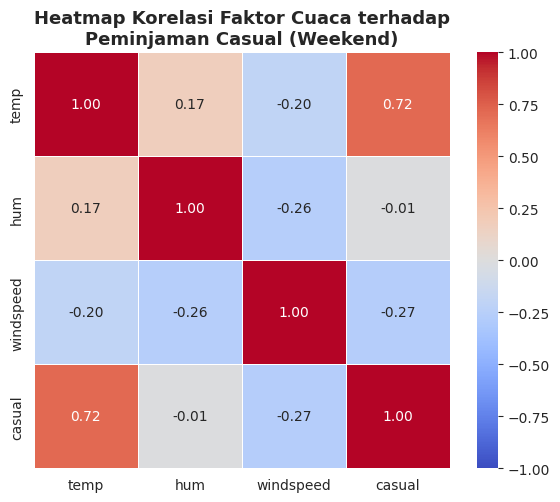

In [83]:
# hitung korelasi
corr_matrix = weekend[["temp","hum","windspeed","casual"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title(
    "Heatmap Korelasi Faktor Cuaca terhadap\nPeminjaman Casual (Weekend)",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

**Insight:**
- Visualisasi scatter plot dan analisis korelasi menunjukkan bahwa suhu merupakan faktor cuaca yang paling berpengaruh terhadap peminjaman sepeda oleh pengguna casual pada akhir pekan. Sebaliknya, kecepatan angin memiliki pengaruh negatif yang lebih lemah, sementara kelembapan tidak menunjukkan hubungan yang signifikan.
- Semakin tinggi suhu, jumlah peminjaman casual pada akhir pekan cenderung meningkat secara konsisten.
- Kecepatan angin yang lebih tinggi cenderung berkaitan dengan penurunan jumlah peminjaman casual, meskipun pengaruhnya tidak sekuat suhu.

### Pertanyaan 2:

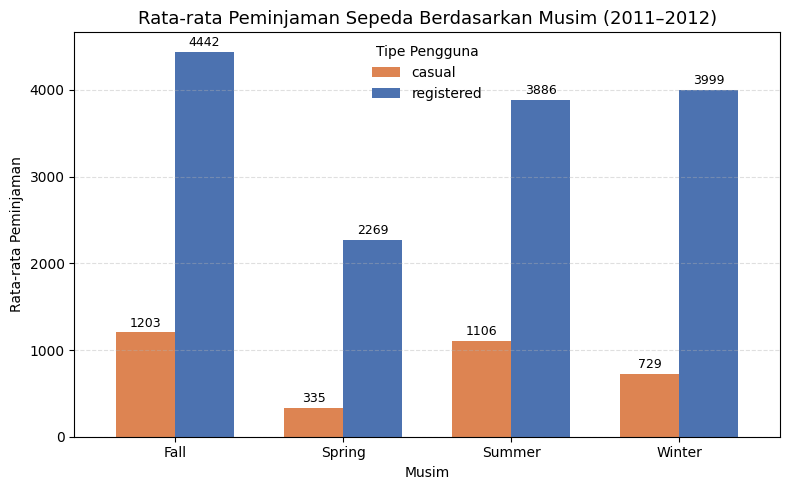

In [78]:
ax = season_avg.plot(
    kind="bar",
    figsize=(8,5),
    color=["#DD8452", "#4C72B0"],  # casual, registered
    width=0.7
)

# judul & label
ax.set_title(
    "Rata-rata Peminjaman Sepeda Berdasarkan Musim (2011–2012)",
    fontsize=13,
)
ax.set_xlabel("Musim")
ax.set_ylabel("Rata-rata Peminjaman")

# legend
ax.legend(
    title="Tipe Pengguna",
    frameon=False
)

# grid tipis
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# angka di atas bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        label_type="edge",
        fontsize=9,
        padding=2
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
- Fall
1. Registered mencapai rata-rata tertinggi dibanding musim lain
2. Casual juga berada pada level tertinggi
3. Menunjukkan musim paling ramai untuk bike sharing

- Spring
1. Merupakan musim dengan rata-rata peminjaman terendah bagi kedua tipe pengguna
2. Perbedaan antara casual dan registered tetap signifikan dengan dominasi pengguna registered

- Summer
1. Rata-rata peminjaman meningkat tajam dibanding Spring
2. Casual dan registered sama-sama mengalami kenaikan, menandakan kondisi cuaca yang lebih mendukung
3. Perbedaan antara casual dan registered tetap signifikan dengan dominasi pengguna registered

- Winter
1. Registered tetap menunjukkan angka tinggi dan stabil
2. Casual menurun dibanding Summer dan Fall, mengindikasikan sensitivitas yang lebih besar terhadap kondisi musim dingin

Pengguna registered memiliki pola peminjaman yang lebih stabil dan konsisten sepanjang musim, sementara pengguna casual menunjukkan fluktuasi yang lebih besar, dengan peningkatan pada musim yang lebih hangat dan penurunan pada musim dingin.

## Analisis Lanjutan: Clustering (Rule Based Segmentation)

Tujuan: Mengelompokkan kondisi cuaca akhir pekan ke dalam segmen tertentu untuk melihat perbedaan rata-rata peminjaman casual.

In [44]:
# filter data akhir pekan
weekend = df_day[df_day["workingday"] == 0].copy()

In [74]:
# binning suhu
weekend["temp_bin"] = pd.cut(
    weekend["temp"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"]
)

# binning kelembapan
weekend["hum_bin"] = pd.cut(
    weekend["hum"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

# binning kecepatan angin
weekend["wind_bin"] = pd.cut(
    weekend["windspeed"],
    bins=[0, 0.2, 0.4, 1],
    labels=["Low", "Medium", "High"]
)

def weather_segment(row):
    if row["temp_bin"] == "High" and row["wind_bin"] == "Low" and row["hum_bin"] != "High":
        return "Perfect Ride"
    elif row["temp_bin"] == "Medium":
        return "Comfortable"
    else:
        return "Challenging"

weekend["weather_segment"] = weekend.apply(weather_segment, axis=1)


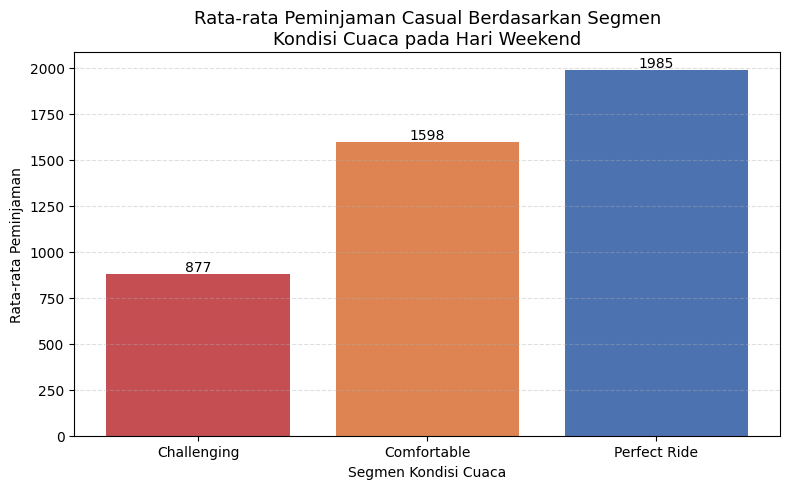

In [75]:
import matplotlib.pyplot as plt

# hitung rata-rata
segment_avg = weekend.groupby("weather_segment")["casual"].mean()

# tentukan urutan
order = ["Challenging", "Comfortable", "Perfect Ride"]
segment_avg = segment_avg.reindex(order)

# warna konsisten
colors = {
    "Perfect Ride": "#4C72B0",
    "Comfortable": "#DD8452",
    "Challenging": "#C44E52"
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_avg.index,
    segment_avg.values,
    color=[colors[s] for s in segment_avg.index]
)

plt.title(
    "Rata-rata Peminjaman Casual Berdasarkan Segmen\nKondisi Cuaca pada Hari Weekend",
    fontsize=13
)
plt.xlabel("Segmen Kondisi Cuaca")
plt.ylabel("Rata-rata Peminjaman")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


## Conclusion

#### **Pertanyaan 1**
> Bagaimana pengaruh suhu, kecepatan angin, dan kelembapan terhadap rata-rata peminjaman sepeda pengguna casual pada akhir pekan (2011-2012)?

Berdasarkan analisis visualisasi scatter plot, heatmap korelasi, serta analisis lanjutan menggunakan rule-based segmentation (binning dan clustering manual), dapat disimpulkan bahwa suhu merupakan faktor cuaca yang paling berpengaruh terhadap peminjaman sepeda oleh pengguna casual pada akhir pekan. Peningkatan suhu menunjukkan kecenderungan peningkatan jumlah peminjaman casual secara konsisten.

Sebaliknya, kecepatan angin memiliki hubungan negatif yang lebih lemah, di mana peminjaman cenderung menurun pada kondisi angin yang lebih kencang, sementara kelembapan tidak menunjukkan hubungan yang signifikan terhadap peminjaman casual. Analisis lanjutan berbasis segmentasi kondisi cuaca memperkuat temuan ini, di mana segmen cuaca paling ideal menghasilkan rata-rata peminjaman casual tertinggi dibandingkan segmen lainnya.

Temuan ini mengindikasikan bahwa pengguna casual lebih sensitif terhadap kenyamanan cuaca, terutama pada aktivitas rekreasional di akhir pekan.

#### **Pertanyaan 2**
> Bagaimana perbandingan rata-rata jumlah peminjaman pengguna casual dan registered pada setiap musim (2011–2012)?

Hasil analisis menunjukkan bahwa pengguna registered secara konsisten mendominasi rata-rata peminjaman sepeda pada seluruh musim, yang mencerminkan pola penggunaan yang lebih rutin dan stabil. Sementara itu, pengguna casual menunjukkan variasi musiman yang lebih besar, dengan peningkatan peminjaman yang lebih jelas pada musim Summer dan Fall, serta penurunan pada Spring dan Winter.